In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
crime_df = pd.read_csv('data/crimes_with_station_lists.csv')
weekday_df = pd.read_csv('data/CATS_Ridership_Weekday.csv')
saturday_df = pd.read_csv('data/CATS_Ridership_Saturday.csv')
sunday_df = pd.read_csv('data/CATS_Ridership_Sunday.csv')
crime_df.head(5)

,LOCATION,ZIP,LATITUDE_PUBLIC,LONGITUDE_PUBLIC,CMPD_PATROL_DIVISION,NPA,DATE_INCIDENT_BEGAN,LOCATION_TYPE_DESCRIPTION,PLACE_TYPE_DESCRIPTION,PLACE_DETAIL_DESCRIPTION,HIGHEST_NIBRS_DESCRIPTION,cluster,cluster_title,nearest_station,stations_in_radius,stations_in_radius_dist_m
0,200 E TRADE ST,28202,35.226243,-80.841973,Central,476,2018/11/17 00:00:00+00,Outdoors,Open Area,Street/Highway,Drug/Narcotic Violations,1,"""Regulatory and Non-Violent Offenses""",7th Street,"CTC/Arena,3rd St/Convention,7th Street","147.71,308.3,372.2"
1,200 E TRADE ST,28202,35.226243,-80.841973,Central,476,2018/11/17 00:00:00+00,Outdoors,Open Area,Street/Highway,Drug/Narcotic Violations,1,"""Regulatory and Non-Violent Offenses""",CTC/Arena,"CTC/Arena,3rd St/Convention,7th Street","147.71,308.3,372.2"
2,200 E TRADE ST,28202,35.226243,-80.841973,Central,476,2018/11/17 00:00:00+00,Outdoors,Open Area,Street/Highway,Drug/Narcotic Violations,1,"""Regulatory and Non-Violent Offenses""",3rd St/Convention,"CTC/Arena,3rd St/Convention,7th Street","147.71,308.3,372.2"
3,400 S DAVIDSON ST,28204,35.220123,-80.841999,Central,476,2018/12/21 00:00:00+00,Outdoors,Open Area,Street/Highway,Theft From Motor Vehicle,8,Theft and Vehicle Offenses,3rd St/Convention,"3rd St/Convention,Brooklyn Village","398.58,471.1"
4,400 S DAVIDSON ST,28204,35.220123,-80.841999,Central,476,2018/12/21 00:00:00+00,Outdoors,Open Area,Street/Highway,Theft From Motor Vehicle,8,Theft and Vehicle Offenses,Brooklyn Village,"3rd St/Convention,Brooklyn Village","398.58,471.1"


In [3]:
crime_df['nearest_station'].value_counts()

nearest_station
CTC/Arena            11197
3rd St/Convention     8755
7th Street            8510
9th Street            4738
Bland                 3643
East/West             3304
Brooklyn Village      2608
Carson                1002
Name: count, dtype: int64

In [4]:
ctc_crime_df = crime_df[crime_df['stations_in_radius'].str.contains('CTC')]
convention_crime_df = crime_df[crime_df['stations_in_radius'].str.contains('Convention')]
street_7th_crime_df = crime_df[crime_df['stations_in_radius'].str.contains('7th')]
street_9th_crime_df = crime_df[crime_df['stations_in_radius'].str.contains('9th')]
bland_crime_df = crime_df[crime_df['stations_in_radius'].str.contains('Bland')]
east_west_crime_df = crime_df[crime_df['stations_in_radius'].str.contains('East')]
brooklyn_village_crime_df = crime_df[crime_df['stations_in_radius'].str.contains('Brooklyn')]
carson_crime_df = crime_df[crime_df['stations_in_radius'].str.contains('Carson')]
print('CTC crimes:', len(ctc_crime_df))
print('Convention crimes:', len(convention_crime_df))
print('7th Street crimes:', len(street_7th_crime_df))
print('9th Street crimes:', len(street_9th_crime_df))
print('Bland crimes:', len(bland_crime_df))
print('East/West crimes:', len(east_west_crime_df))
print('Brooklyn Village crimes:', len(brooklyn_village_crime_df))
print('Carson crimes:', len(carson_crime_df))

CTC crimes: 26736
Convention crimes: 20404
7th Street crimes: 20959
9th Street crimes: 7757
Bland crimes: 4619
East/West crimes: 4182
Brooklyn Village crimes: 5461
Carson crimes: 1485


In [5]:
weekday_df["Average"] = weekday_df.iloc[:, 1:].mean(axis=1)
saturday_df["Average"] = saturday_df.iloc[:, 1:].mean(axis=1)
sunday_df["Average"] = sunday_df.iloc[:, 1:].mean(axis=1)
overall_ridership_df = (
    weekday_df[["Station", "Average"]]
        .rename(columns={"Average": "Average_Weekday"})
        .merge(
            saturday_df[["Station", "Average"]]
                .rename(columns={"Average": "Average_Saturday"}),
            on="Station"
        )
        .merge(
            sunday_df[["Station", "Average"]]
                .rename(columns={"Average": "Average_Sunday"}),
            on="Station"
        )
)
overall_ridership_df["Overall_Average"] = overall_ridership_df[["Average_Weekday", "Average_Saturday", "Average_Sunday"]].mean(axis=1)
overall_ridership_df

,Station,Average_Weekday,Average_Saturday,Average_Sunday,Overall_Average
0,3rd St/Convention,1149.764706,641.205882,398.794118,729.921569
1,7th Street,610.264706,563.882353,329.117647,501.088235
2,9th Street,402.088235,359.970588,274.529412,345.529412
3,Bland,429.617647,706.029412,289.029412,474.892157
4,Brooklyn Village,925.970588,736.294118,470.588235,710.950980
5,Carson,293.235294,334.852941,181.705882,269.931373
6,CTC/Arena,2565.676471,1792.000000,1270.205882,1875.960784
7,East/West,740.382353,991.352941,496.205882,742.647059


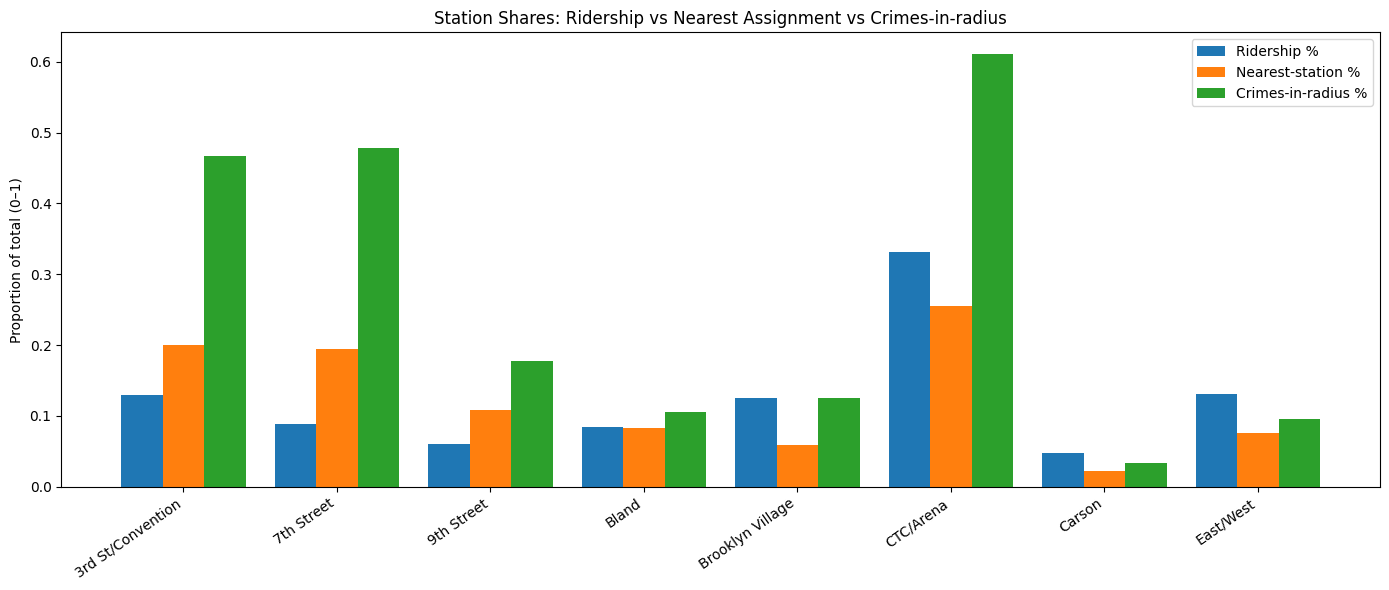

In [6]:
ridership_share = (
    overall_ridership_df
    .set_index("Station")["Overall_Average"]
    .div(overall_ridership_df["Overall_Average"].sum())
)

nearest_share = crime_df["nearest_station"].value_counts(normalize=True)

station_patterns = {
    "CTC/Arena": "CTC",
    "3rd St/Convention": "Convention",
    "7th Street": "7th",
    "9th Street": "9th",
    "Bland": "Bland",
    "East/West": "East",
    "Brooklyn Village": "Brooklyn",
    "Carson": "Carson",
}

crime_in_radius_counts = pd.Series({
    station: crime_df["stations_in_radius"].astype(str).str.contains(pattern, na=False).sum()
    for station, pattern in station_patterns.items()
})

crime_in_radius_share = crime_in_radius_counts / len(crime_df)

stations = sorted(set(ridership_share.index) | set(nearest_share.index) | set(crime_in_radius_share.index))

plot_df = pd.DataFrame({
    "Ridership %": ridership_share.reindex(stations).fillna(0),
    "Nearest-station %": nearest_share.reindex(stations).fillna(0),
    "Crimes-in-radius %": crime_in_radius_share.reindex(stations).fillna(0),
}, index=stations)

x = np.arange(len(plot_df.index))
width = 0.27

plt.figure(figsize=(14, 6))
plt.bar(x - width, plot_df["Ridership %"], width, label="Ridership %")
plt.bar(x,         plot_df["Nearest-station %"], width, label="Nearest-station %")
plt.bar(x + width, plot_df["Crimes-in-radius %"], width, label="Crimes-in-radius %")

plt.xticks(x, plot_df.index, rotation=35, ha="right")
plt.ylabel("Proportion of total (0–1)")
plt.title("Station Shares: Ridership vs Nearest Assignment vs Crimes-in-radius")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
overall_ridership_df.to_csv('data/overall_ridership.csv', index=False)